<a href="https://colab.research.google.com/github/Roua-Elayeb/artificial-intelligence-mini-projects/blob/main/TP5_Pr%C3%A9vision_multi_horizon_de_temp%C3%A9rature_avec_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow scikit-learn matplotlib pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Toutes les bibliothèques importées avec succès ")

TensorFlow version: 2.20.0
Toutes les bibliothèques importées avec succès 


In [3]:
# ── 1. Chargement du CSV depuis l'URL ──────────────────────────────────────
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(URL, header=0)

print("Shape brut :", df.shape)
print(df.head())

Shape brut : (3650, 2)
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


In [4]:
# ── 2. Conversion de la colonne Temp en float32 ────────────────────────────
df['Temp'] = df['Temp'].astype(np.float32)

# ── 3. Conversion de la colonne Date en datetime ──────────────────────────
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)
print(f"\nPériode : {df['Date'].min()} → {df['Date'].max()}")
print(f"Nombre de jours : {len(df)}")

Date    datetime64[ns]
Temp           float32
dtype: object

Période : 1981-01-01 00:00:00 → 1990-12-31 00:00:00
Nombre de jours : 3650


In [5]:
# ── 4. Variables saisonnières (sin/cos du jour de l'année) ─────────────────
df['doy'] = df['Date'].dt.day_of_year  # jour de l'année : 1..365

df['sin_doy'] = np.sin(2 * np.pi * df['doy'] / 365).astype(np.float32)
df['cos_doy'] = np.cos(2 * np.pi * df['doy'] / 365).astype(np.float32)

print(df[['Date', 'Temp', 'doy', 'sin_doy', 'cos_doy']].head(10))

        Date       Temp  doy   sin_doy   cos_doy
0 1981-01-01  20.700001    1  0.017213  0.999852
1 1981-01-02  17.900000    2  0.034422  0.999407
2 1981-01-03  18.799999    3  0.051620  0.998667
3 1981-01-04  14.600000    4  0.068802  0.997630
4 1981-01-05  15.800000    5  0.085965  0.996298
5 1981-01-06  15.800000    6  0.103102  0.994671
6 1981-01-07  15.800000    7  0.120208  0.992749
7 1981-01-08  17.400000    8  0.137279  0.990532
8 1981-01-09  21.799999    9  0.154309  0.988023
9 1981-01-10  20.000000   10  0.171293  0.985220


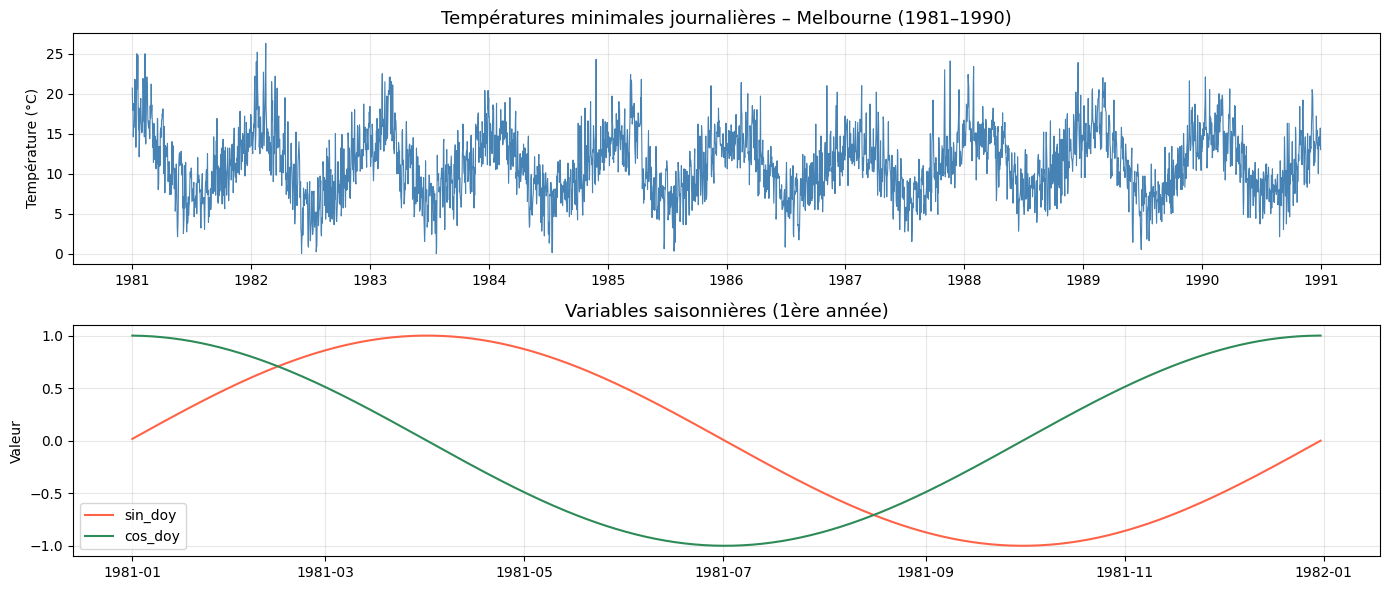

Figure 1 sauvegardée.


In [6]:
# ── Visualisation : extrait de la série temporelle ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(df['Date'], df['Temp'], color='steelblue', linewidth=0.8)
axes[0].set_title('Températures minimales journalières – Melbourne (1981–1990)', fontsize=13)
axes[0].set_ylabel('Température (°C)')
axes[0].grid(alpha=0.3)

axes[1].plot(df['Date'][:365], df['sin_doy'][:365], label='sin_doy', color='tomato')
axes[1].plot(df['Date'][:365], df['cos_doy'][:365], label='cos_doy', color='seagreen')
axes[1].set_title('Variables saisonnières (1ère année)', fontsize=13)
axes[1].set_ylabel('Valeur')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure1_serie_et_saison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardée.")

In [7]:
# ── Séparation temporelle Train / Test (80% / 20%) ────────────────────────
N = len(df)
train_size = int(N * 0.80)

df_train = df.iloc[:train_size].copy()
df_test  = df.iloc[train_size:].copy()

print(f"Train : {len(df_train)} jours  ({df_train['Date'].min()} → {df_train['Date'].max()})")
print(f"Test  : {len(df_test)}  jours  ({df_test['Date'].min()} → {df_test['Date'].max()})")

Train : 2920 jours  (1981-01-01 00:00:00 → 1988-12-30 00:00:00)
Test  : 730  jours  (1989-01-01 00:00:00 → 1990-12-31 00:00:00)


In [8]:
# ── Normalisation de Temp uniquement avec MinMaxScaler ────────────────────
# IMPORTANT : fit sur TRAIN seulement → aucune fuite de données du test
scaler = MinMaxScaler(feature_range=(0, 1))

df_train['temp_norm'] = scaler.fit_transform(df_train[['Temp']]).astype(np.float32)
df_test['temp_norm']  = scaler.transform(df_test[['Temp']]).astype(np.float32)

print("Train – Temp normalisée :")
print(f"  min={df_train['temp_norm'].min():.4f}, max={df_train['temp_norm'].max():.4f}")
print("Test – Temp normalisée :")
print(f"  min={df_test['temp_norm'].min():.4f}, max={df_test['temp_norm'].max():.4f}")
print("\nsin_doy et cos_doy déjà dans [-1,1], pas de normalisation supplémentaire.")

Train – Temp normalisée :
  min=0.0000, max=1.0000
Test – Temp normalisée :
  min=0.0190, max=0.8403

sin_doy et cos_doy déjà dans [-1,1], pas de normalisation supplémentaire.


In [9]:
# ── Construction des tableaux de features F=3 ─────────────────────────────
# Features = [temp_norm, sin_doy, cos_doy]
features_train = df_train[['temp_norm', 'sin_doy', 'cos_doy']].values.astype(np.float32)
features_test  = df_test[['temp_norm', 'sin_doy', 'cos_doy']].values.astype(np.float32)

target_train = df_train['temp_norm'].values.astype(np.float32)
target_test  = df_test['temp_norm'].values.astype(np.float32)

print("features_train shape :", features_train.shape)  # (N_train, 3)
print("features_test  shape :", features_test.shape)

features_train shape : (2920, 3)
features_test  shape : (730, 3)


In [10]:
def create_dataset_multi(dataset_features, target_temp_norm, look_back=30, horizon=7):
    """
    dataset_features  : array shape (N, n_features)
    target_temp_norm  : array shape (N,) ou (N,1)
    returns :
        X : (samples, look_back, n_features)
        y : (samples, horizon)
    """
    target = target_temp_norm.flatten()  # assure (N,)
    X_list, y_list = [], []

    # Nombre max de fenêtres possibles sans dépasser la fin de série
    max_i = len(dataset_features) - look_back - horizon + 1

    for i in range(max_i):
        # Fenêtre d'entrée : indices [i, i+look_back)
        Xi = dataset_features[i : i + look_back]          # (look_back, n_features)
        # Cible multi-horizon : indices [i+look_back, i+look_back+horizon)
        yi = target[i + look_back : i + look_back + horizon]  # (horizon,)

        X_list.append(Xi)
        y_list.append(yi)

    X = np.array(X_list, dtype=np.float32)  # (samples, look_back, n_features)
    y = np.array(y_list, dtype=np.float32)  # (samples, horizon)
    return X, y


# ── Paramètres ─────────────────────────────────────────────────────────────
LOOK_BACK = 30
HORIZON   = 7

# ── Construction séparée sur train et test ────────────────────────────────
X_train, y_train = create_dataset_multi(features_train, target_train,
                                        look_back=LOOK_BACK, horizon=HORIZON)
X_test,  y_test  = create_dataset_multi(features_test,  target_test,
                                        look_back=LOOK_BACK, horizon=HORIZON)

print("X_train shape :", X_train.shape)   # (samples_train, 30, 3)
print("y_train shape :", y_train.shape)   # (samples_train, 7)
print("X_test  shape :", X_test.shape)
print("y_test  shape :", y_test.shape)

X_train shape : (2884, 30, 3)
y_train shape : (2884, 7)
X_test  shape : (694, 30, 3)
y_test  shape : (694, 7)


In [11]:
# ── Baseline : répéter la dernière température observée de la fenêtre ──────
# X_test[:, -1, 0] = dernière temp_norm de chaque fenêtre (feature 0)
last_obs = X_test[:, -1, 0]          # shape (samples_test,)
y_pred_baseline = np.tile(last_obs.reshape(-1, 1), (1, HORIZON))  # (samples_test, 7)

# ── Métriques globales ────────────────────────────────────────────────────
mae_baseline  = mean_absolute_error(y_test.flatten(), y_pred_baseline.flatten())
rmse_baseline = np.sqrt(mean_squared_error(y_test.flatten(), y_pred_baseline.flatten()))

print(f"Baseline – MAE  (normalisé) : {mae_baseline:.4f}")
print(f"Baseline – RMSE (normalisé) : {rmse_baseline:.4f}")

# ── MAE par horizon (colonne par colonne) ─────────────────────────────────
mae_per_horizon_baseline = [mean_absolute_error(y_test[:, h], y_pred_baseline[:, h])
                             for h in range(HORIZON)]

print("\nMAE Baseline par horizon :")
for h, mae_h in enumerate(mae_per_horizon_baseline, start=1):
    print(f"  J+{h} : {mae_h:.4f}")

Baseline – MAE  (normalisé) : 0.0993
Baseline – RMSE (normalisé) : 0.1259

MAE Baseline par horizon :
  J+1 : 0.0744
  J+2 : 0.0957
  J+3 : 0.1026
  J+4 : 0.1043
  J+5 : 0.1067
  J+6 : 0.1072
  J+7 : 0.1044


In [12]:
# ── Validation temporelle : 10% dernières fenêtres du train ───────────────
val_size = int(len(X_train) * 0.10)
X_val, y_val         = X_train[-val_size:], y_train[-val_size:]
X_tr_final, y_tr_final = X_train[:-val_size], y_train[:-val_size]

print(f"Train effectif : {X_tr_final.shape[0]} fenêtres")
print(f"Validation     : {X_val.shape[0]} fenêtres")

# ── Callback EarlyStopping ────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

Train effectif : 2596 fenêtres
Validation     : 288 fenêtres


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Modèle 1 : SimpleRNN
# ═══════════════════════════════════════════════════════════════════════════
model_rnn = keras.Sequential([
    layers.Input(shape=(LOOK_BACK, 3)),
    layers.SimpleRNN(50, activation='tanh'),
    layers.Dense(HORIZON)
], name='SimpleRNN_model')

model_rnn.compile(loss='mse', optimizer='adam')
model_rnn.summary()

history_rnn = model_rnn.fit(
    X_tr_final, y_tr_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,057 (11.94 KB)

 Trainable params: 3,057 (11.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0626 - val_loss: 0.0127
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0128 - val_loss: 0.0123
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0122 - val_loss: 0.0124
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0119 - val_loss: 0.0123
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0116 - val_loss: 0.0122
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0115 - val_loss: 0.0120
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0114 - val_loss: 0.0119
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0113 - val_loss: 0.0118
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0112 - val_loss: 0.0117
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0112 - val_loss: 0.0116
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0111 - val_loss: 0.0116
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss:

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# Modèle 2 : LSTM
# ═══════════════════════════════════════════════════════════════════════════
early_stop2 = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

model_lstm = keras.Sequential([
    layers.Input(shape=(LOOK_BACK, 3)),
    layers.LSTM(50, activation='tanh'),
    layers.Dense(HORIZON)
], name='LSTM_model')

model_lstm.compile(loss='mse', optimizer='adam')
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_tr_final, y_tr_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop2],
    verbose=1
)

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,157 (43.58 KB)

 Trainable params: 11,157 (43.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0393 - val_loss: 0.0108
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0113 - val_loss: 0.0109
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0113 - val_loss: 0.0108
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0113 - val_loss: 0.0107
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0113 - val_loss: 0.0107
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0113 - val_loss: 0.0107
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0112 - val_loss: 0.0106
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0112 - val_loss: 0.0106
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0111 - val_loss: 0.0107
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

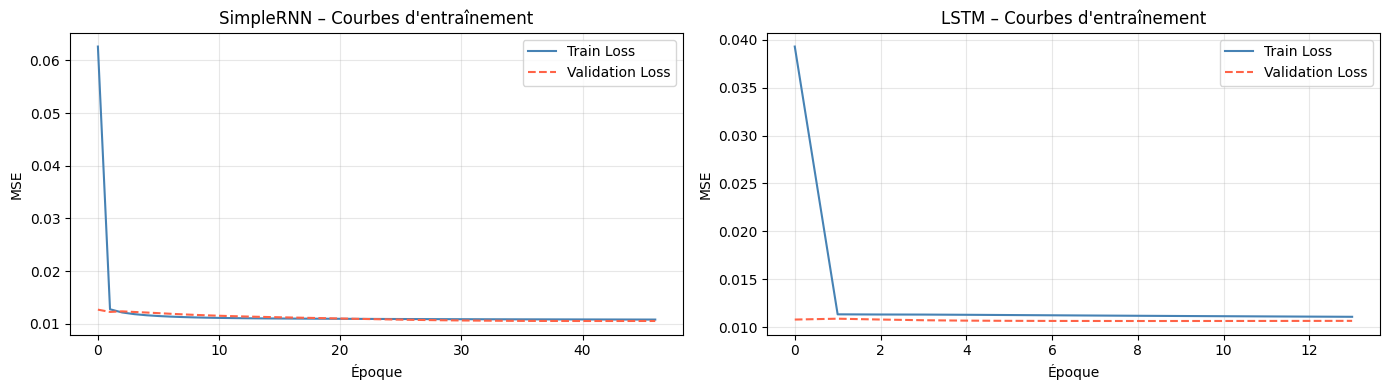

Figure 2 sauvegardée.


In [15]:
# ── Courbes d'entraînement : loss & val_loss ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, title in zip(axes,
                               [history_rnn, history_lstm],
                               ['SimpleRNN – Courbes d\'entraînement',
                                'LSTM – Courbes d\'entraînement']):
    ax.plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    ax.plot(history.history['val_loss'], label='Validation Loss', color='tomato',
            linestyle='--')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Époque')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure2_courbes_entrainement.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 sauvegardée.")

In [16]:
# ── Métriques sur le test ─────────────────────────────────────────────────
y_pred_rnn  = model_rnn.predict(X_test,  verbose=0)
y_pred_lstm = model_lstm.predict(X_test, verbose=0)

def compute_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    print(f"{name:15s} | MAE  = {mae:.4f} | RMSE = {rmse:.4f}")
    return mae, rmse

print("─" * 50)
print(f"{'Modèle':15s} | MAE            | RMSE")
print("─" * 50)
mae_b,    rmse_b    = compute_metrics(y_test, y_pred_baseline, 'Baseline')
mae_rnn,  rmse_rnn  = compute_metrics(y_test, y_pred_rnn,      'SimpleRNN')
mae_lstm, rmse_lstm = compute_metrics(y_test, y_pred_lstm,     'LSTM')
print("─" * 50)

──────────────────────────────────────────────────
Modèle          | MAE            | RMSE
──────────────────────────────────────────────────
Baseline        | MAE  = 0.0993 | RMSE = 0.1259
SimpleRNN       | MAE  = 0.0758 | RMSE = 0.0971
LSTM            | MAE  = 0.0760 | RMSE = 0.0977
──────────────────────────────────────────────────


In [17]:
# ── MAE par horizon pour les 3 modèles ───────────────────────────────────
mae_per_h_rnn  = [mean_absolute_error(y_test[:, h], y_pred_rnn[:, h])  for h in range(HORIZON)]
mae_per_h_lstm = [mean_absolute_error(y_test[:, h], y_pred_lstm[:, h]) for h in range(HORIZON)]

horizons = [f'J+{h+1}' for h in range(HORIZON)]
print(f"\n{'Horizon':8s} | {'Baseline':10s} | {'SimpleRNN':10s} | {'LSTM':10s}")
print("-" * 48)
for h in range(HORIZON):
    print(f"{horizons[h]:8s} | {mae_per_horizon_baseline[h]:.4f}     | "
          f"{mae_per_h_rnn[h]:.4f}     | {mae_per_h_lstm[h]:.4f}")


Horizon  | Baseline   | SimpleRNN  | LSTM      
------------------------------------------------
J+1      | 0.0744     | 0.0667     | 0.0728
J+2      | 0.0957     | 0.0763     | 0.0762
J+3      | 0.1026     | 0.0787     | 0.0777
J+4      | 0.1043     | 0.0772     | 0.0768
J+5      | 0.1067     | 0.0771     | 0.0764
J+6      | 0.1072     | 0.0774     | 0.0751
J+7      | 0.1044     | 0.0775     | 0.0770


In [18]:
# ── Choix du meilleur modèle (LSTM généralement) ──────────────────────────
# On compare les MAE globales
best_model_name = 'LSTM' if mae_lstm <= mae_rnn else 'SimpleRNN'
best_pred_norm  = y_pred_lstm if mae_lstm <= mae_rnn else y_pred_rnn
print(f"Meilleur modèle : {best_model_name}")

# ── Inversion du MinMaxScaler ─────────────────────────────────────────────
# scaler attend shape (n, 1) → reshape, inverse, puis revenir à (n, 7)
def inverse_scale(arr_norm, scaler):
    """arr_norm : (samples, horizon) → retourne (samples, horizon) en °C"""
    n, h = arr_norm.shape
    flat = arr_norm.reshape(-1, 1)              # (n*h, 1)
    flat_inv = scaler.inverse_transform(flat)   # (n*h, 1)
    return flat_inv.reshape(n, h)               # (n, h) en °C

y_test_celsius = inverse_scale(y_test,          scaler)
y_pred_celsius = inverse_scale(best_pred_norm,  scaler)

print("y_test_celsius shape :", y_test_celsius.shape)
print("y_pred_celsius shape :", y_pred_celsius.shape)

Meilleur modèle : SimpleRNN
y_test_celsius shape : (694, 7)
y_pred_celsius shape : (694, 7)


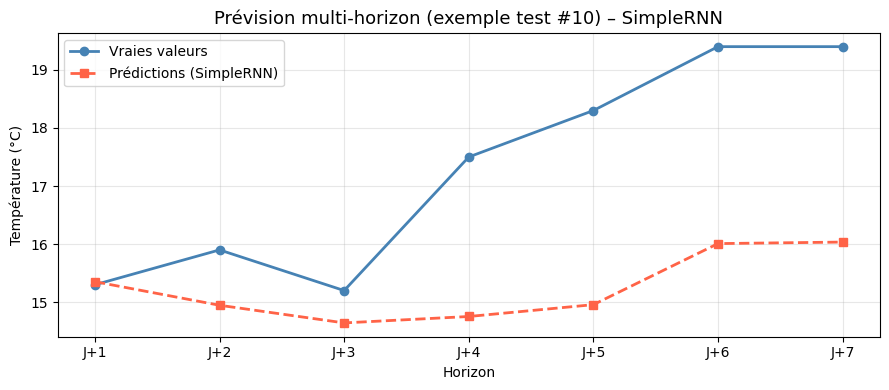

Figure 3 sauvegardée.


In [19]:
# ── Visualisation : exemple de prévision multi-horizon (indice i=10) ──────
i = 10   # indice dans le test

fig, ax = plt.subplots(figsize=(9, 4))
horizons_labels = [f'J+{h+1}' for h in range(HORIZON)]

ax.plot(horizons_labels, y_test_celsius[i],  marker='o', label='Vraies valeurs',
        color='steelblue', linewidth=2)
ax.plot(horizons_labels, y_pred_celsius[i],  marker='s', label=f'Prédictions ({best_model_name})',
        color='tomato', linewidth=2, linestyle='--')

ax.set_title(f'Prévision multi-horizon (exemple test #{i}) – {best_model_name}', fontsize=13)
ax.set_xlabel('Horizon')
ax.set_ylabel('Température (°C)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_prevision_multi_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 sauvegardée.")

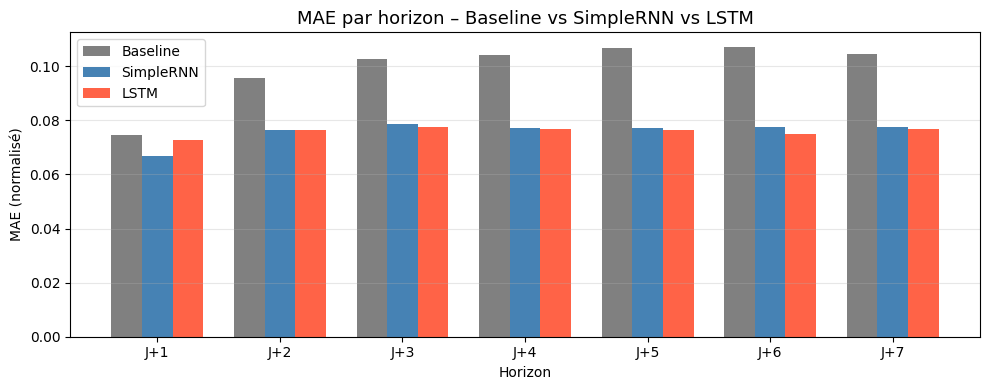

Figure 4 sauvegardée.


In [20]:
# ── Graphique MAE par horizon (comparaison 3 modèles) ─────────────────────
x = np.arange(HORIZON)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, mae_per_horizon_baseline, width, label='Baseline', color='gray')
ax.bar(x,         mae_per_h_rnn,            width, label='SimpleRNN', color='steelblue')
ax.bar(x + width, mae_per_h_lstm,           width, label='LSTM', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(horizons_labels)
ax.set_xlabel('Horizon')
ax.set_ylabel('MAE (normalisé)')
ax.set_title('MAE par horizon – Baseline vs SimpleRNN vs LSTM', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figure4_mae_par_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 sauvegardée.")

In [21]:
# ── Tableau comparatif final ──────────────────────────────────────────────
results = pd.DataFrame({
    'Modèle'  : ['Baseline (Persistance)', 'SimpleRNN', 'LSTM'],
    'MAE (normalisé)' : [mae_b,   mae_rnn,  mae_lstm],
    'RMSE (normalisé)': [rmse_b,  rmse_rnn, rmse_lstm],
})
results = results.sort_values('MAE (normalisé)').reset_index(drop=True)

print("\n=== Tableau comparatif (espace normalisé [0,1]) ===")
print(results.to_string(index=False, float_format='{:.4f}'.format))

# ── Conversion approximative en degrés Celsius ───────────────────────────
# MAE en °C ≈ MAE_norm × (max_temp - min_temp)
temp_range = float(scaler.data_max_[0] - scaler.data_min_[0])
results['MAE (°C)']  = results['MAE (normalisé)']  * temp_range
results['RMSE (°C)'] = results['RMSE (normalisé)'] * temp_range

print(f"\n=== Tableau comparatif (°C, plage = {temp_range:.1f}°C) ===")
print(results[['Modèle', 'MAE (°C)', 'RMSE (°C)']].to_string(index=False,
      float_format='{:.3f}'.format))


=== Tableau comparatif (espace normalisé [0,1]) ===
                Modèle  MAE (normalisé)  RMSE (normalisé)
             SimpleRNN           0.0758            0.0971
                  LSTM           0.0760            0.0977
Baseline (Persistance)           0.0993            0.1259

=== Tableau comparatif (°C, plage = 26.3°C) ===
                Modèle  MAE (°C)  RMSE (°C)
             SimpleRNN     1.994      2.553
                  LSTM     1.999      2.570
Baseline (Persistance)     2.612      3.312
